<a href="https://colab.research.google.com/github/vishalmahor886/basic_ML_code/blob/main/handling_missing_values(num).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("vennela18/data-science-job")

100%|██████████| 247k/247k [00:00<00:00, 51.8MB/s]

Extracting files...


# Handling missing value
# drop values

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os


In [ ]:
df = pd.read_csv(os.path.join(path, "data_science_job.csv"))

In [ ]:
df.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
525,28415,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14.0,NaN,NaN,60.0,0.0
13500,4084,city_103,0.920,Male,Has relevent experience,no_enrollment,Masters,STEM,16.0,1000-4999,Pvt Ltd,15.0,0.0
717,6407,city_114,0.926,NaN,Has relevent experience,Full time course,High School,NaN,7.0,NaN,NaN,82.0,0.0
15907,19216,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,10.0,1000-4999,Pvt Ltd,11.0,0.0
4164,6121,city_57,0.866,Male,Has relevent experience,no_enrollment,Phd,STEM,20.0,100-500,NGO,116.0,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


In [ ]:
#check null percentage

df.isnull().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [ ]:
df.shape

(19158, 13)

In [ ]:
## find columns in which only 5 % null

cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [ ]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
9792,0.887,Full time course,NaN,14.0,43.0
16537,0.920,Full time course,Graduate,6.0,21.0
9622,NaN,no_enrollment,Graduate,20.0,35.0
8730,0.915,no_enrollment,Graduate,6.0,74.0
16766,0.923,no_enrollment,Masters,20.0,12.0


In [ ]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [ ]:
new_df = df[cols].dropna()

In [ ]:
df.shape, new_df.shape

((19158, 13), (17182, 5))

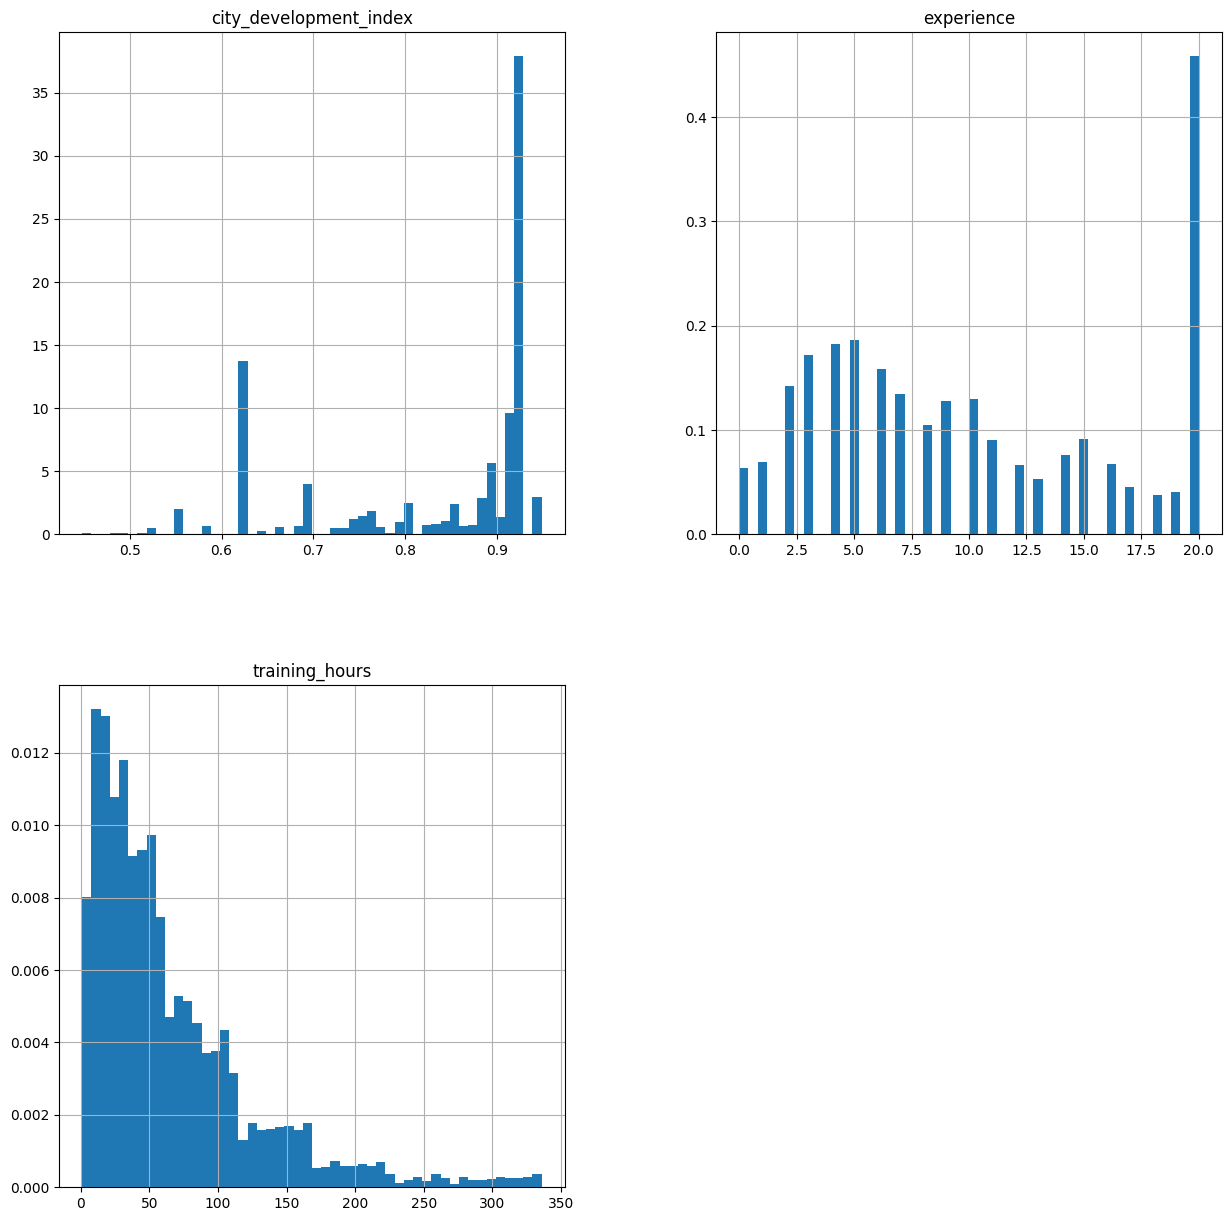

In [ ]:
new_df.hist(bins=50, density=True, figsize=(15,15))
plt.show()

Text(0.5, 1.0, 'Experience')

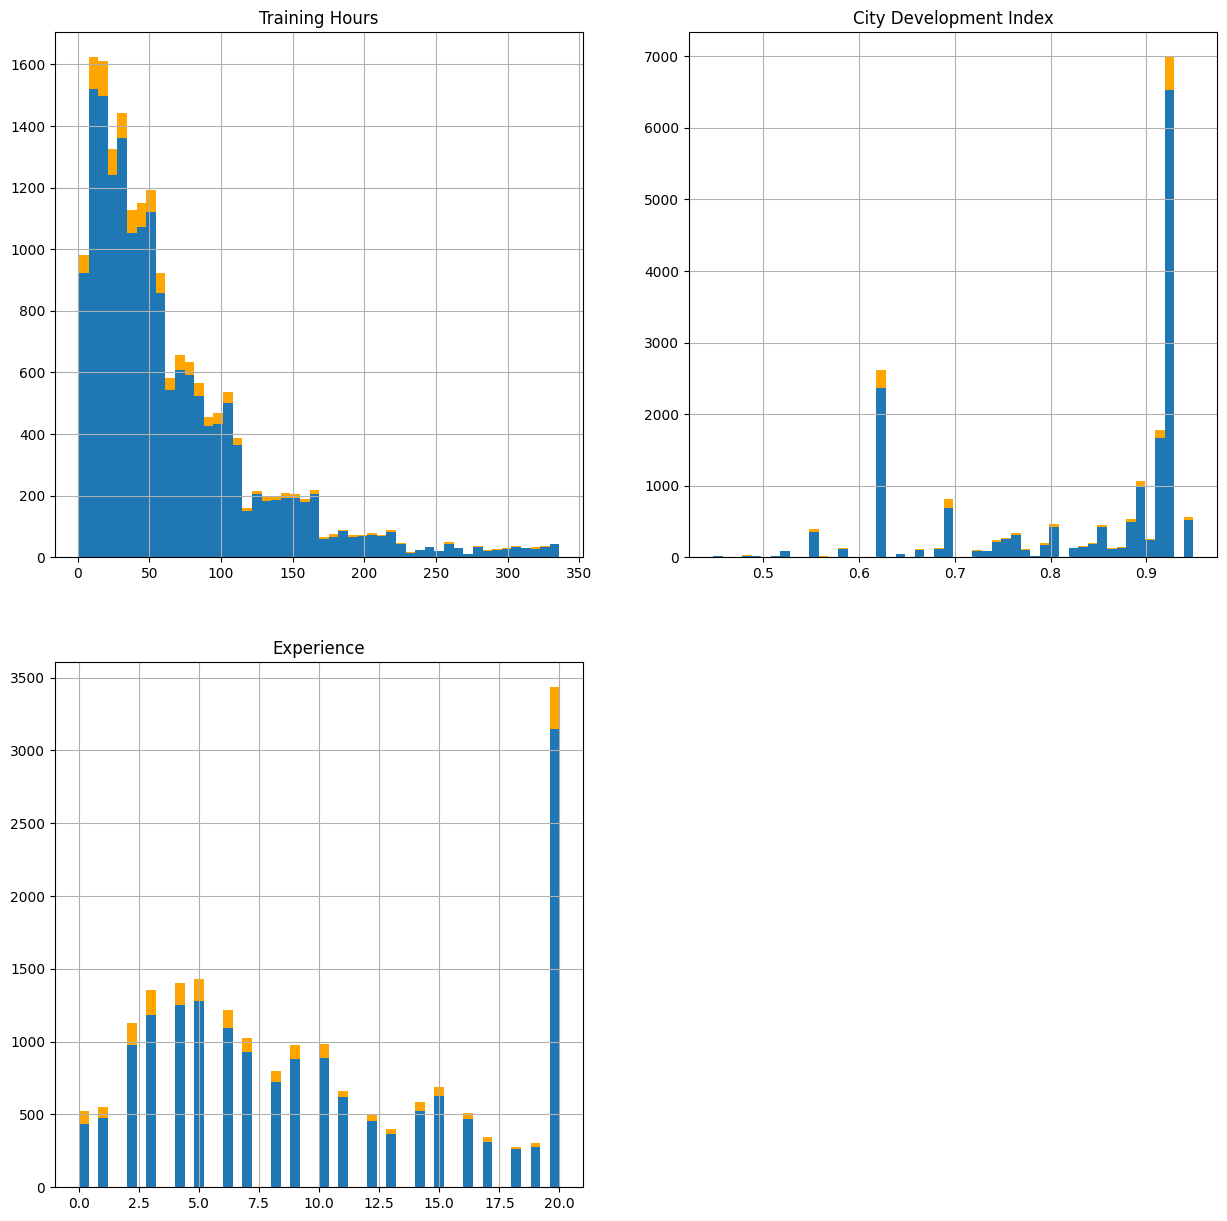

In [ ]:
plt.figure(figsize=(15,15))
plt.subplot(221)
df['training_hours'].hist(bins = 50, color='orange')
new_df['training_hours'].hist(bins = 50)
plt.title('Training Hours')


plt.subplot(222)
df['city_development_index'].hist(bins = 50, color='orange')
new_df['city_development_index'].hist(bins = 50)
plt.title('City Development Index')


plt.subplot(223)
df['experience'].hist(bins = 50, color='orange')
new_df['experience'].hist(bins = 50)
plt.title('Experience')


Text(0.5, 1.0, 'Experience')

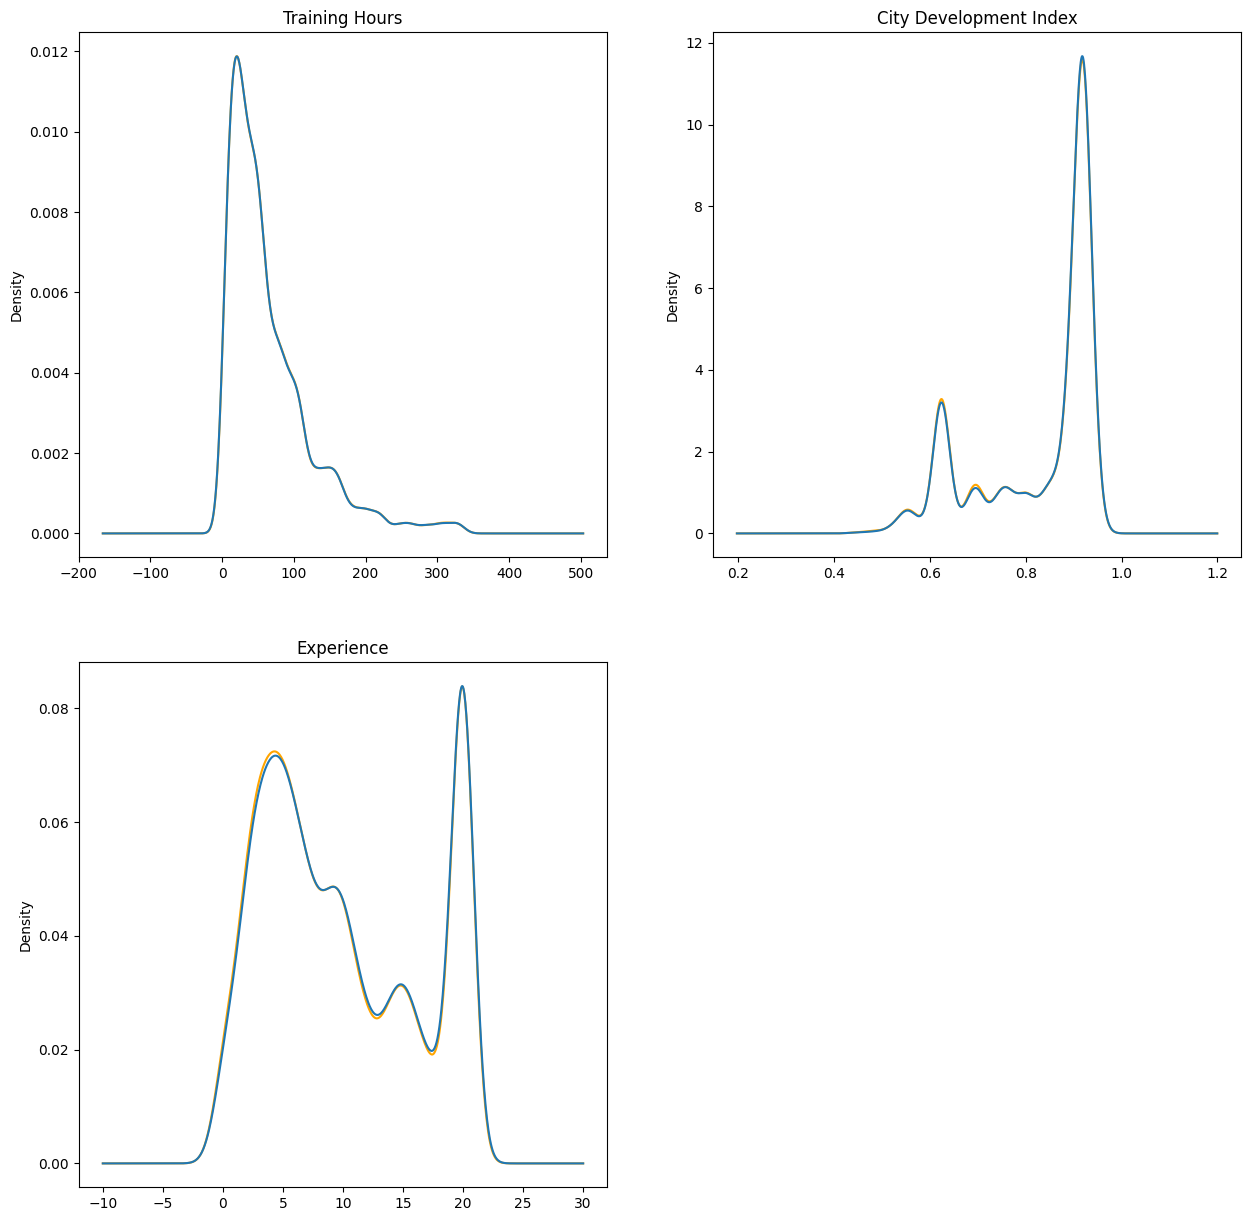

In [ ]:
plt.figure(figsize=(15,15))
plt.subplot(221)
df['training_hours'].plot.density( color='orange')
new_df['training_hours'].plot.density()
plt.title('Training Hours')


plt.subplot(222)
df['city_development_index'].plot.density(color='orange')
new_df['city_development_index'].plot.density()
plt.title('City Development Index')


plt.subplot(223)
df['experience'].plot.density( color='orange')
new_df['experience'].plot.density()
plt.title('Experience')

In [ ]:
df['education_level'].value_counts()

,count
education_level,
Graduate,11598
Masters,4361
High School,2017
Phd,414
Primary School,308


In [ ]:
temp = pd.concat([
    df['education_level'].value_counts()/len(df),
    df['education_level'].value_counts()/len(new_df)
],
                 axis=1)

temp.columns = ['original', 'cca']

In [ ]:
temp

,original,cca
education_level,,
Graduate,0.605387,0.675009
Masters,0.227633,0.253812
High School,0.105282,0.117390
Phd,0.021610,0.024095
Primary School,0.016077,0.017926


In [ ]:
temp = pd.concat([
    df['enrolled_university'].value_counts()/len(df),
    df['enrolled_university'].value_counts()/len(new_df)
],
                 axis=1)

temp.columns = ['original', 'cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.804156
Full time course,0.196106,0.218659
Part time course,0.062533,0.069724


# add impute missing data

In [ ]:
import kagglehub
path = kagglehub.dataset_download("yasserh/titanic-dataset")

Using Colab cache for faster access to the 'titanic-dataset' dataset.


In [ ]:
titanic = pd.read_csv(os.path.join(path, "Titanic-Dataset.csv"), usecols=['Age', 'Fare', 'SibSp', 'Parch', 'Survived'])

In [ ]:
titanic.sample(5)

,Survived,Age,SibSp,Parch,Fare
429,1,32.0,0,0,8.0500
480,0,9.0,5,2,46.9000
703,0,25.0,0,0,7.7417
169,0,28.0,0,0,56.4958
849,1,NaN,1,0,89.1042


In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   SibSp     891 non-null    int64  
 3   Parch     891 non-null    int64  
 4   Fare      891 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 34.9 KB


In [ ]:
titanic.isnull().mean()*100

,0
Survived,0.00000
Age,19.86532
SibSp,0.00000
Parch,0.00000
Fare,0.00000


In [ ]:
titanic.isnull().mean()*100

,0
Survived,0.00000
Age,19.86532
SibSp,0.00000
Parch,0.00000
Fare,0.00000


In [ ]:

## add 5% missing values in Fare
# Randomly select 5% of rows
missing_idx = titanic.sample(frac=0.05, random_state=42).index

# Set Fare to NaN for those rows
titanic.loc[missing_idx, 'Fare'] = np.nan

In [ ]:
titanic.isnull().mean()*100

,0
Survived,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Fare,5.050505


In [ ]:
## train test split
from sklearn.model_selection import train_test_split

In [ ]:
x = titanic.drop(columns=['Survived'])
y = titanic['Survived']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=0)

In [ ]:
x_train.shape, x_test.shape

((623, 4), (268, 4))

In [ ]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()

mean_fare = x_train['Fare'].mean()
median_fare = x_train['Fare'].median()




In [ ]:
x_train['Age_median'] = x_train['Age'].fillna(median_age)
x_train['Age_mean'] = x_train['Age'].fillna(mean_age)

x_train['Fare_median'] = x_train['Fare'].fillna(median_fare)
x_train['Fare_mean'] = x_train['Fare'].fillna(mean_fare)

In [ ]:
x_train.sample(5)

,Age,SibSp,Parch,Fare,Age_median,Age_mean,Fare_median,Fare_mean
227,20.5,0,0,7.2500,20.5,20.500000,7.2500,7.250000
709,NaN,1,1,NaN,29.0,29.915339,15.0729,32.893265
373,22.0,0,0,135.6333,22.0,22.000000,135.6333,135.633300
717,27.0,0,0,10.5000,27.0,27.000000,10.5000,10.500000
453,49.0,1,0,89.1042,49.0,49.000000,89.1042,89.104200


In [ ]:
print(x_train['Age'].var())
print(x_train['Age_median'].var())
print(x_train['Age_mean'].var())

210.45286924636747
169.64401397346137
169.51268085599708


In [ ]:
print(x_train['Fare'].var())
print(x_train['Fare_median'].var())
print(x_train['Fare_mean'].var())

# note: when we impute mean or median imputation at that time variance srink because of most of the value comes near to mean

2418.0336751463824
2319.4126667448363
2305.295770678143


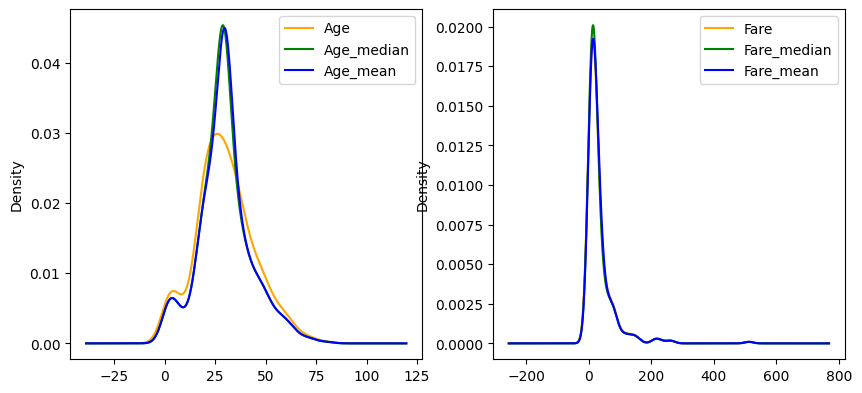

In [ ]:
fig = plt.figure(figsize=(10,10))

ax=plt.subplot(221)

x_train['Age'].plot(kind='kde', color='orange', ax=ax)
x_train['Age_median'].plot(kind='kde', color = 'green', ax=ax)
x_train['Age_mean'].plot(kind='kde', color = 'blue', ax=ax)
plt.legend(['Age', 'Age_median', 'Age_mean'])



ax1 = plt.subplot(222)

x_train['Fare'].plot(kind='kde', color='orange' , ax=ax1)
x_train['Fare_median'].plot(kind='kde', color = 'green', ax=ax1)
x_train['Fare_mean'].plot(kind='kde', color = 'blue', ax=ax1)
plt.legend(['Fare', 'Fare_median', 'Fare_mean'] )


In [ ]:
x_train.cov()

,Age,SibSp,Parch,Fare,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.452869,-3.834684,-2.251423,79.627975,210.452869,210.452869,78.578906,76.647236
SibSp,-3.834684,1.352315,0.400051,8.701966,-3.126547,-3.088708,8.393878,8.296247
Parch,-2.251423,0.400051,0.692366,9.174612,-1.786097,-1.813446,8.873046,8.746857
Fare,79.627975,8.701966,9.174612,2418.033675,66.115096,64.755928,2418.033675,2418.033675
Age_median,210.452869,-3.126547,-1.786097,66.115096,169.644014,169.512681,64.676767,63.032559
Age_mean,210.452869,-3.088708,-1.813446,64.755928,169.512681,169.512681,63.292656,61.736761
Fare_median,78.578906,8.393878,8.873046,2418.033675,64.676767,63.292656,2319.412667,2305.295771
Fare_mean,76.647236,8.296247,8.746857,2418.033675,63.032559,61.736761,2305.295771,2305.295771


In [ ]:
x_train.corr()

,Age,SibSp,Parch,Fare,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,-0.298338,-0.177487,0.105320,1.000000,1.000000,0.106742,0.104416
SibSp,-0.298338,1.000000,0.413436,0.150519,-0.206422,-0.204003,0.149877,0.148587
Parch,-0.177487,0.413436,1.000000,0.221528,-0.164804,-0.167392,0.221419,0.218938
Fare,0.105320,0.150519,0.221528,1.000000,0.101919,0.099870,1.000000,1.000000
Age_median,1.000000,-0.206422,-0.164804,0.101919,1.000000,0.999613,0.103107,0.100793
Age_mean,1.000000,-0.204003,-0.167392,0.099870,0.999613,1.000000,0.100940,0.098760
Fare_median,0.106742,0.149877,0.221419,1.000000,0.103107,0.100940,1.000000,0.996952
Fare_mean,0.104416,0.148587,0.218938,1.000000,0.100793,0.098760,0.996952,1.000000


<Axes: >

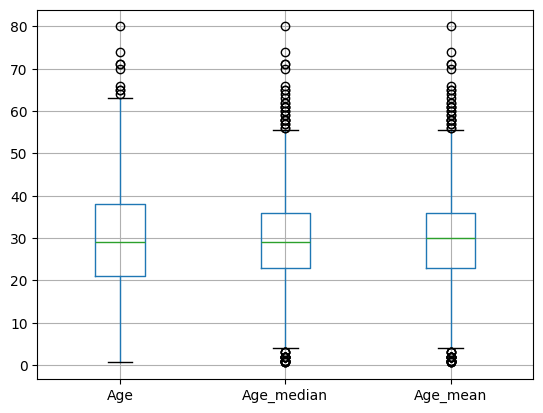

In [ ]:
x_train[['Age','Age_median','Age_mean']].boxplot()

<Axes: >

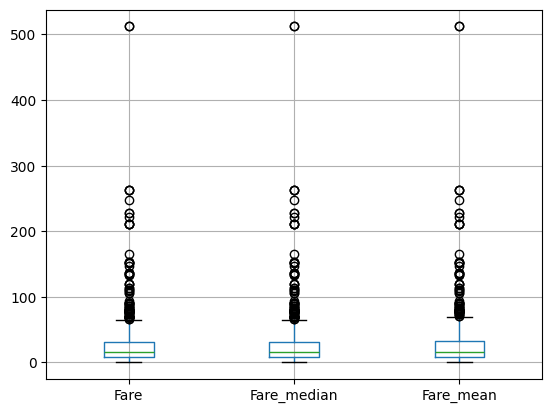

In [ ]:
x_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

#using Sklearn

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(x,y,test_size=0.2, random_state=0)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')


In [ ]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder='passthrough'
)

In [ ]:
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [ ]:
trf.named_transformers_['imputer1'].statistics_

array([29.])

In [ ]:
trf.named_transformers_['imputer2'].statistics_

array([32.36940858])

In [ ]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [ ]:
X_train

array([[29.        , 15.2458    ,  0.        ,  2.        ],
       [31.        , 32.36940858,  0.        ,  0.        ],
       [31.        , 37.0042    ,  1.        ,  1.        ],
       ...,
       [29.        ,  7.7333    ,  0.        ,  0.        ],
       [36.        , 17.4       ,  1.        ,  0.        ],
       [60.        , 39.        ,  1.        ,  1.        ]])

# Arbitaray Value imputation


* using Pandas
* Using skLearn



In [ ]:
# using pandas
## train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=0)

In [ ]:
x_train.sample(5)

,Age,SibSp,Parch,Fare
830,15.0,1,0,14.4542
303,NaN,0,0,12.3500
275,63.0,1,0,77.9583
772,57.0,0,0,10.5000
685,25.0,1,2,41.5792


In [ ]:
x_train.mean()

,0
Age,29.915339
SibSp,0.531300
Parch,0.393258
Fare,32.893265


In [ ]:
x_train.describe()

,Age,SibSp,Parch,Fare
count,502.000000,623.000000,623.000000,594.000000
mean,29.915339,0.531300,0.393258,32.893265
std,14.506994,1.162891,0.832085,49.173506
min,0.670000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,7.925000
50%,29.000000,0.000000,0.000000,15.072900
75%,38.000000,1.000000,0.000000,31.387500
max,80.000000,8.000000,6.000000,512.329200


In [ ]:
x_train['Age_99'] = x_train['Age'].fillna(99)
x_train['Age_minus'] = x_train['Age'].fillna(-1)

x_train['Fare_999'] = x_train['Fare'].fillna(999)
x_train['Fare_minus'] = x_train['Fare'].fillna(-1)

In [ ]:
x_train.sample(5)

,Age,SibSp,Parch,Fare,Age_99,Age_minus,Fare_999,Fare_minus
711,NaN,0,0,26.550,99.0,-1.0,26.550,26.550
787,8.0,4,1,29.125,8.0,8.0,29.125,29.125
394,24.0,0,2,16.700,24.0,24.0,16.700,16.700
139,24.0,0,0,79.200,24.0,24.0,79.200,79.200
751,6.0,0,1,12.475,6.0,6.0,12.475,12.475


In [ ]:
print(x_train['Age'].var())
print(x_train['Age_99'].var())
print(x_train['Age_minus'].var())


210.45286924636747
917.6372579490387
319.3288446599532


In [ ]:
print(x_train['Fare'].var())
print(x_train['Fare_999'].var())
print(x_train['Fare_minus'].var())

2418.0336751463824
43796.51822879445
2356.3618874732947


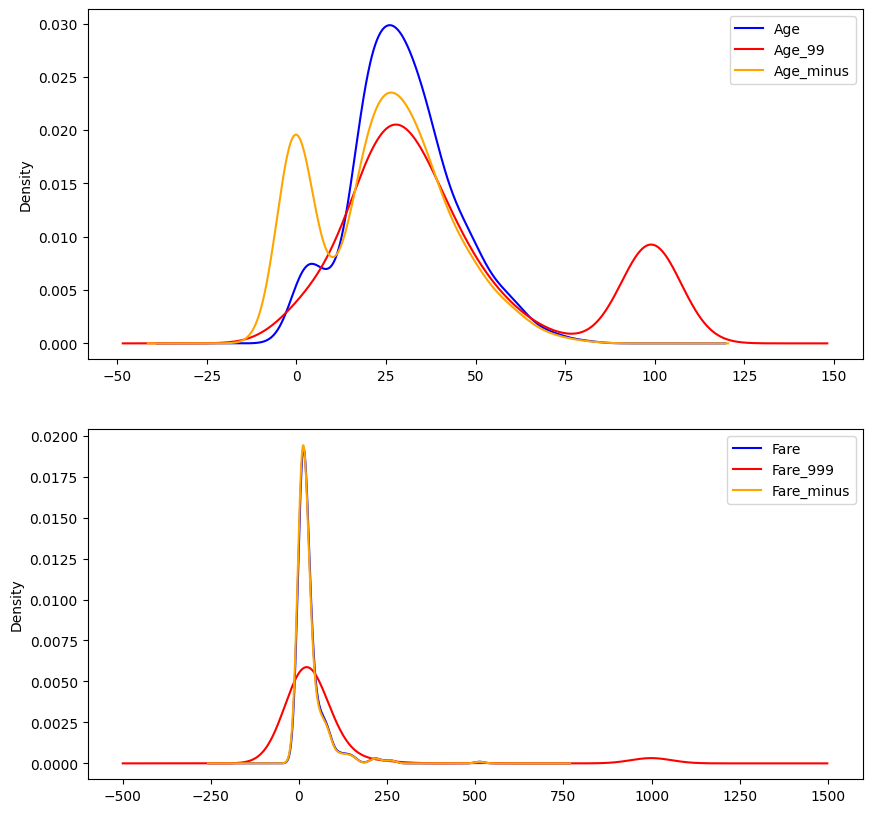

In [ ]:
fig = plt.figure(figsize=(10,10))

plt.subplot(211)
x_train['Age'].plot(kind='kde', color='blue')

x_train['Age_99'].plot(kind='kde', color='red')

x_train['Age_minus'].plot(kind='kde', color='orange')
plt.legend(['Age', 'Age_99', 'Age_minus'])


plt.subplot(212)
x_train['Fare'].plot(kind='kde', color='blue')

x_train['Fare_999'].plot(kind='kde', color='red')

x_train['Fare_minus'].plot(kind='kde', color='orange')
plt.legend(['Fare', 'Fare_999', 'Fare_minus'])

In [ ]:
## Using Sk learn

## simple Imputer class

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=0)

In [ ]:
x_train.sample(5)

,Age,SibSp,Parch,Fare
730,29.0,0,0,211.3375
90,29.0,0,0,8.0500
152,55.5,0,0,8.0500
547,NaN,0,0,13.8625
881,33.0,0,0,7.8958


In [ ]:
simple_imputer99 = SimpleImputer(strategy='constant', fill_value=99)
simple_imputer999 = SimpleImputer(strategy='constant', fill_value=999)

In [ ]:
## ColumnTransormer

trf1 = ColumnTransformer([
    ('simple_imputer99',
     simple_imputer99,
     ['Age']),
    ('simple_imputer999',
     simple_imputer999,
     ['Fare'])
])

In [ ]:
trf1.fit(x_train)

ColumnTransformer(transformers=[('simple_imputer99',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('simple_imputer999',
                                 SimpleImputer(fill_value=999,
                                               strategy='constant'),
                                 ['Fare'])])

In [ ]:
x_train = trf1.transform(x_train)
x_test = trf1.transform(x_test)

In [ ]:
trf1.named_transformers_['simple_imputer99'].statistics_

array([99.])

In [ ]:
trf1.named_transformers_['simple_imputer999'].statistics_

array([999.])